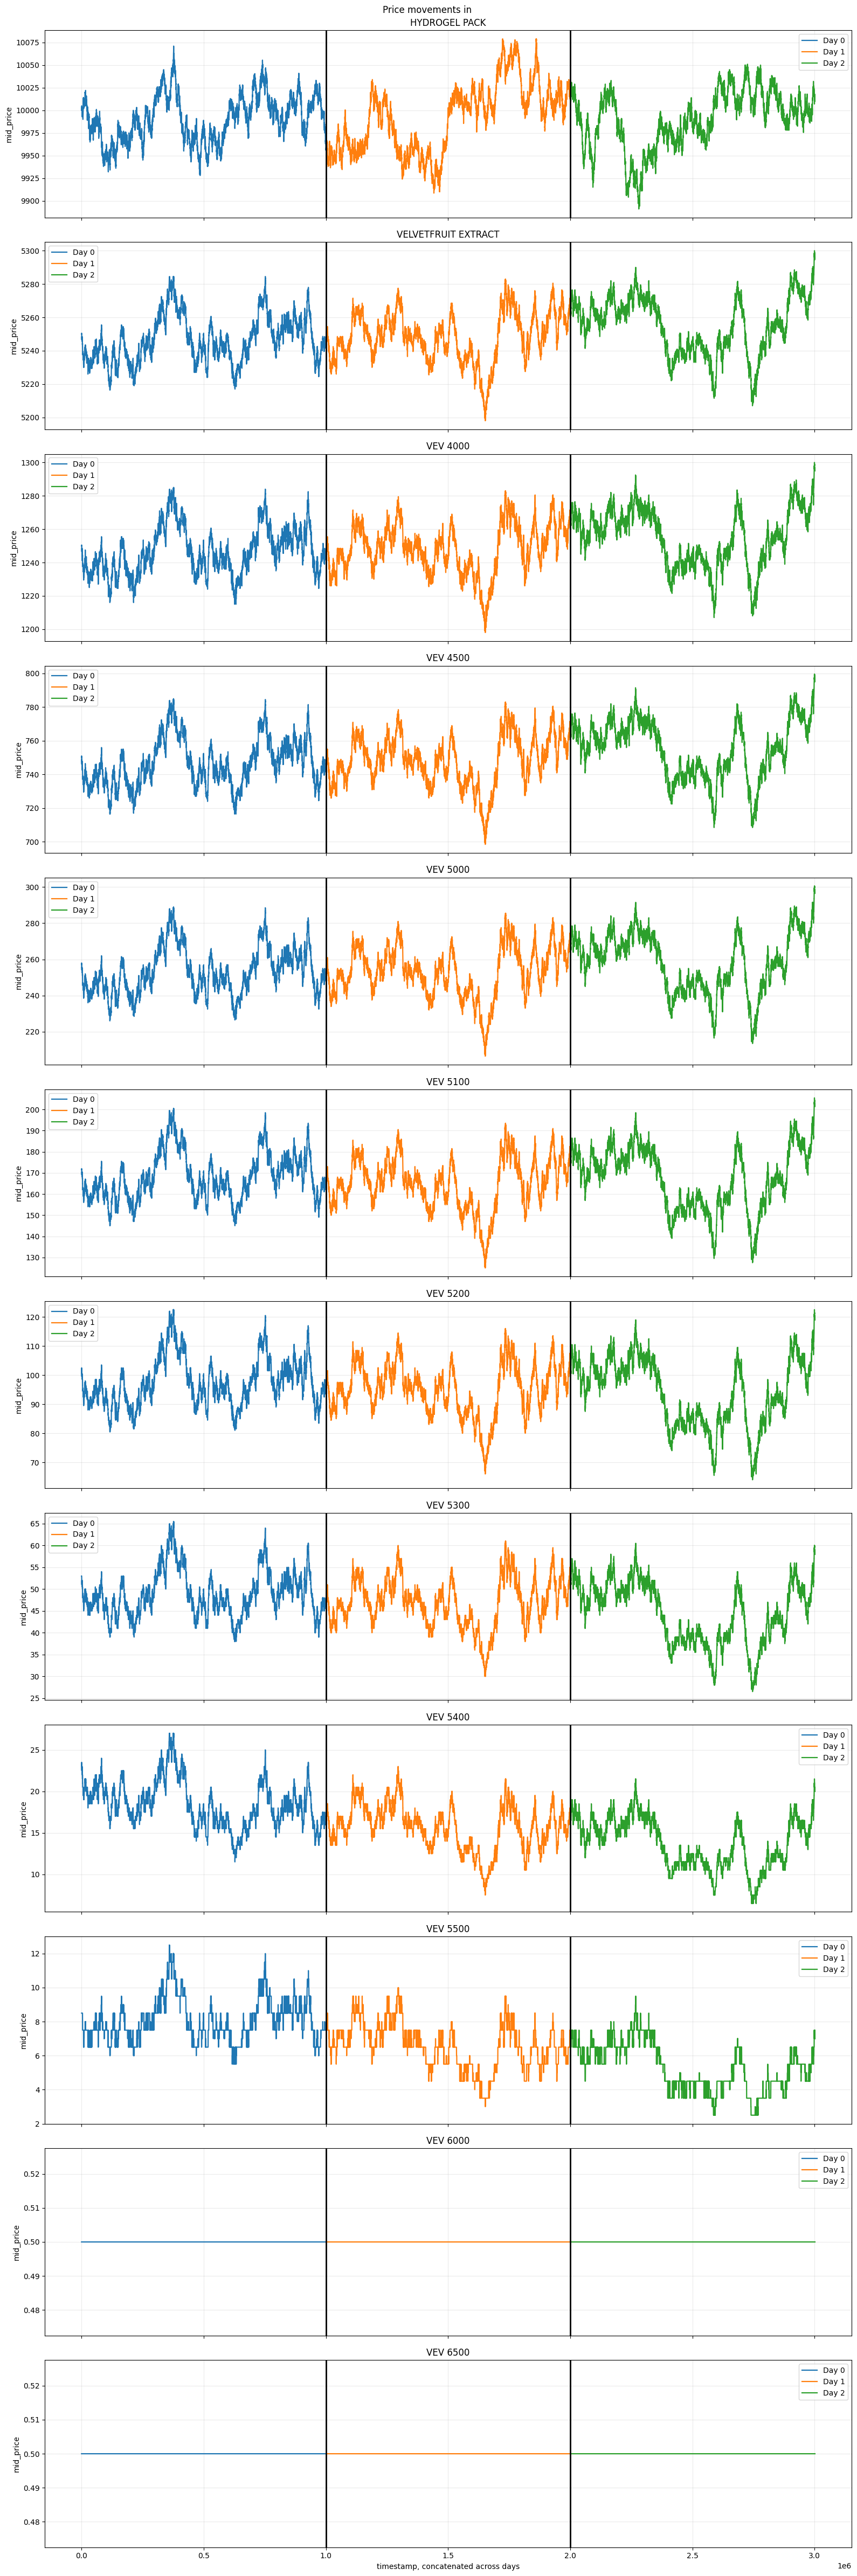

In [13]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ROUND_NUMBER = 3
ROUND_FOLDER = Path(".")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
plot_prices = prices.loc[prices["mid_price"] > 0].copy()
products = sorted(plot_prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = plot_prices[plot_prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = plot_prices[plot_prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


In [14]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets


PRODUCTS = ("EMERALDS", "TOMATOES")
LEVELS = (1, 2, 3)


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "backtest" / "resources",
        Path.cwd().parent / "backtest" / "resources",
    ]
    for root in search_roots:
        test_path = (root / path).resolve()
        if test_path.exists():
            return test_path

    raise FileNotFoundError(f"Could not find CSV file: {path}")


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


def cumulative_depth(row: pd.Series, side: str) -> tuple[list[float], list[float]]:
    price_volume: dict[float, float] = {}

    for level in LEVELS:
        price = row.get(f"{side}_price_{level}")
        volume = row.get(f"{side}_volume_{level}")

        if pd.isna(price) or pd.isna(volume) or volume <= 0:
            continue

        price_value = float(price)
        volume_value = float(volume)
        price_volume[price_value] = price_volume.get(price_value, 0.0) + volume_value

    if not price_volume:
        return [], []

    reverse = side == "bid"
    prices = sorted(price_volume.keys(), reverse=reverse)

    cumulative = []
    running = 0.0
    for price in prices:
        running += price_volume[price]
        cumulative.append(running)

    return prices, cumulative


def draw_product_depth(ax: plt.Axes, row: pd.Series, product: str) -> None:
    ax.clear()

    bid_prices, bid_cum = cumulative_depth(row, "bid")
    ask_prices, ask_cum = cumulative_depth(row, "ask")

    if bid_prices:
        ax.step(bid_prices, bid_cum, where="post", color="tab:green", linewidth=2, label="Bids")
        ax.fill_between(bid_prices, bid_cum, step="post", alpha=0.25, color="tab:green")

    if ask_prices:
        ax.step(ask_prices, ask_cum, where="post", color="tab:red", linewidth=2, label="Asks")
        ax.fill_between(ask_prices, ask_cum, step="post", alpha=0.25, color="tab:red")

    mid_price = row.get("mid_price")
    if pd.notna(mid_price):
        ax.axvline(float(mid_price), linestyle="--", linewidth=1.5, color="tab:blue", label="Mid")

    best_bid = row.get("bid_price_1")
    best_ask = row.get("ask_price_1")
    spread_text = ""
    if pd.notna(best_bid) and pd.notna(best_ask):
        spread_text = f" | Spread: {float(best_ask) - float(best_bid):.2f}"

    ax.set_title(f"{product}{spread_text}")
    ax.set_xlabel("Price")
    ax.set_ylabel("Cumulative Volume")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")


def run_visualizer(path: str = "prices_round_0_day_-1.csv") -> None:
    df = load_prices(path)

    filtered = df[df["product"].isin(PRODUCTS)].copy()
    if filtered.empty:
        raise ValueError("No rows found for EMERALDS or TOMATOES in the provided file.")

    timestamps = sorted(filtered["timestamp"].dropna().unique())
    if not timestamps:
        raise ValueError("No valid timestamp values found in the provided file.")

    data_by_product = {
        product: (
            filtered[filtered["product"] == product]
            .drop_duplicates(subset=["timestamp"], keep="last")
            .set_index("timestamp")
            .sort_index()
        )
        for product in PRODUCTS
    }

    def row_for_timestamp(product: str, timestamp: float) -> pd.Series | None:
        product_df = data_by_product[product]
        if timestamp not in product_df.index:
            return None
        return product_df.loc[timestamp]

    def plot_at_index(index: int) -> None:
        timestamp = timestamps[int(index)]

        fig = plt.figure(figsize=(14, 6))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
        ax_emeralds = fig.add_subplot(gs[0, 0])
        ax_tomatoes = fig.add_subplot(gs[0, 1])

        emerald_row = row_for_timestamp("EMERALDS", timestamp)
        tomato_row = row_for_timestamp("TOMATOES", timestamp)

        if emerald_row is not None:
            draw_product_depth(ax_emeralds, emerald_row, "EMERALDS")
        else:
            ax_emeralds.set_title("EMERALDS (no data)")

        if tomato_row is not None:
            draw_product_depth(ax_tomatoes, tomato_row, "TOMATOES")
        else:
            ax_tomatoes.set_title("TOMATOES (no data)")

        fig.suptitle(f"Order Book Depth | timestamp={int(timestamp)}", fontsize=14)
        plt.show()

    slider = widgets.IntSlider(
        min=0,
        max=len(timestamps) - 1,
        step=1,
        value=min(11, len(timestamps) - 1),
        description="Time idx",
        continuous_update=True,
        layout=widgets.Layout(width="850px"),
    )

    play = widgets.Play(
        value=slider.value,
        min=slider.min,
        max=slider.max,
        step=1,
        interval=100,  # 10 FPS
        description="Auto",
    )

    play_pause = widgets.ToggleButton(
        value=False,
        description="▶ Play",
        tooltip="Play/Pause at 10 FPS",
        layout=widgets.Layout(width="120px"),
    )

    widgets.jslink((play, "value"), (slider, "value"))

    def on_play_pause(change):
        is_playing = bool(change["new"])
        play_pause.description = "⏸ Pause" if is_playing else "▶ Play"
        if hasattr(play, "playing"):
            play.playing = is_playing
        else:
            play._playing = is_playing

    play_pause.observe(on_play_pause, names="value")

    out = widgets.interactive_output(plot_at_index, {"index": slider})
    controls = widgets.HBox([play_pause, play, slider])
    display(controls, out)

In [15]:
def run_price_levels_window_widget(
    prices_csv: str,
    product: str = "VELVETFRUIT_EXTRACT",
    window_size: int = 50,
    trades_csv: str = "trades_round_3_day_0.csv",
) -> None:
    """Interactive plot of mid/bid/ask price levels with trade overlays."""
    if window_size <= 0:
        raise ValueError("window_size must be > 0")

    df = load_prices(prices_csv)
    asset = product.strip().upper()
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        raise ValueError(f"No rows found for product={asset} in {prices_csv}")

    cols = [
        "timestamp",
        "mid_price",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]
    available_cols = [c for c in cols if c in sub.columns]

    for c in available_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    if "timestamp" not in sub.columns:
        raise ValueError("Missing required column: timestamp")

    sub = (
        sub[available_cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    if sub.empty:
        raise ValueError("No usable timestamp rows after cleaning.")

    trades_path = resolve_data_path(trades_csv)
    trades = pd.read_csv(trades_path, sep=";", engine="python")
    if "price" not in [str(c).strip().lower() for c in trades.columns]:
        trades = pd.read_csv(trades_path, sep=None, engine="python")

    trades.columns = [str(c).strip().lower() for c in trades.columns]
    required_trade_cols = {"timestamp", "symbol", "price"}
    missing_trade_cols = required_trade_cols - set(trades.columns)
    if missing_trade_cols:
        raise ValueError(f"Missing required columns in trades CSV: {sorted(missing_trade_cols)}")

    trades["symbol"] = trades["symbol"].astype(str).str.strip().str.upper()
    trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades = trades.dropna(subset=["timestamp", "price"])
    trades = trades[trades["symbol"] == asset].copy()

    # Custom midpoint: average(highest ask, lowest bid), where each side uses level 3 if
    # available, otherwise level 2.
    if {"ask_price_2", "ask_price_3"}.issubset(sub.columns):
        sub["best_ask_fallback"] = sub["ask_price_3"].where(sub["ask_price_3"].notna(), sub["ask_price_2"])
    else:
        sub["best_ask_fallback"] = np.nan

    if {"bid_price_2", "bid_price_3"}.issubset(sub.columns):
        sub["best_bid_fallback"] = sub["bid_price_3"].where(sub["bid_price_3"].notna(), sub["bid_price_2"])
    else:
        sub["best_bid_fallback"] = np.nan

    sub["fallback_mid"] = (sub["best_ask_fallback"] + sub["best_bid_fallback"]) / 2.0

    # Additional fallback quote ladders for dotted overlays.
    if {"ask_price_1", "ask_price_2"}.issubset(sub.columns):
        sub["second_ask_fallback"] = sub["ask_price_2"].where(sub["ask_price_2"].notna(), sub["ask_price_1"])
    else:
        sub["second_ask_fallback"] = np.nan

    if {"bid_price_1", "bid_price_2"}.issubset(sub.columns):
        sub["second_bid_fallback"] = sub["bid_price_2"].where(sub["bid_price_2"].notna(), sub["bid_price_1"])
    else:
        sub["second_bid_fallback"] = np.nan

    n = len(sub)
    max_start = 0 if n <= window_size else n - window_size

    def plot_window(start_idx: int) -> None:
        start = int(start_idx)
        end = min(start + window_size, n)
        w = sub.iloc[start:end]

        plt.figure(figsize=(13, 5))

        if "mid_price" in w.columns and w["mid_price"].notna().any():
            plt.plot(w["timestamp"], w["mid_price"], color="black", linewidth=2.0, label="mid_price")

        if "fallback_mid" in w.columns and w["fallback_mid"].notna().any():
            plt.plot(
                w["timestamp"],
                w["fallback_mid"],
                color="tab:blue",
                linestyle=":",
                linewidth=2.0,
                alpha=0.95,
                label="fallback_mid (ask3/2 + bid3/2)/2",
            )

        # Dotted fallback quote lines:
        # highest ask (ask3 else ask2), second highest ask (ask2 else ask1),
        # lowest bid (bid3 else bid2), second lowest bid (bid2 else bid1).
        if "best_ask_fallback" in w.columns and w["best_ask_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["best_ask_fallback"],
                color="#B71C1C",
                linestyle=":",
                linewidth=1.8,
                alpha=0.9,
                label="highest ask fallback (3->2)",
            )

        if "second_ask_fallback" in w.columns and w["second_ask_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["second_ask_fallback"],
                color="#E57373",
                linestyle=":",
                linewidth=1.6,
                alpha=0.9,
                label="second highest ask fallback (2->1)",
            )

        if "best_bid_fallback" in w.columns and w["best_bid_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["best_bid_fallback"],
                color="#1B5E20",
                linestyle=":",
                linewidth=1.8,
                alpha=0.9,
                label="lowest bid fallback (3->2)",
            )

        if "second_bid_fallback" in w.columns and w["second_bid_fallback"].notna().any():
            plt.plot(
                w["timestamp"],
                w["second_bid_fallback"],
                color="#81C784",
                linestyle=":",
                linewidth=1.6,
                alpha=0.9,
                label="second lowest bid fallback (2->1)",
            )

        bid_colors = ["#A5D6A7", "#4CAF50", "#1B5E20"]
        if "bid_price_1" in w.columns and w["bid_price_1"].notna().any():
            plt.plot(w["timestamp"], w["bid_price_1"], color=bid_colors[0], linewidth=1.4, alpha=0.95, label="bid_price_1")
        if "bid_price_2" in w.columns and w["bid_price_2"].notna().any():
            plt.plot(w["timestamp"], w["bid_price_2"], color=bid_colors[1], linewidth=1.4, alpha=0.95, label="bid_price_2")
        if "bid_price_3" in w.columns and w["bid_price_3"].notna().any():
            b3 = w[w["bid_price_3"].notna()]
            plt.scatter(b3["timestamp"], b3["bid_price_3"], color=bid_colors[2], s=20, alpha=0.95, label="bid_price_3 (points)")

        ask_colors = ["#FF7F7F", "#D32F2F", "#7B0000"]
        if "ask_price_1" in w.columns and w["ask_price_1"].notna().any():
            plt.plot(w["timestamp"], w["ask_price_1"], color=ask_colors[0], linewidth=1.4, alpha=0.95, label="ask_price_1")
        if "ask_price_2" in w.columns and w["ask_price_2"].notna().any():
            plt.plot(w["timestamp"], w["ask_price_2"], color=ask_colors[1], linewidth=1.4, alpha=0.95, label="ask_price_2")
        if "ask_price_3" in w.columns and w["ask_price_3"].notna().any():
            a3 = w[w["ask_price_3"].notna()]
            plt.scatter(a3["timestamp"], a3["ask_price_3"], color=ask_colors[2], s=20, alpha=0.95, label="ask_price_3 (points)")

        # Overlay trades in current window as X markers.
        t_min = w["timestamp"].min()
        t_max = w["timestamp"].max()
        tw = trades[(trades["timestamp"] >= t_min) & (trades["timestamp"] <= t_max)]
        if not tw.empty:
            plt.scatter(
                tw["timestamp"],
                tw["price"],
                marker="x",
                color="#EFB63A",
                s=72,
                linewidths=3.2,
                alpha=0.9,
                label=f"trades ({len(tw)})",
            )

        t0 = int(w["timestamp"].iloc[0])
        t1 = int(w["timestamp"].iloc[-1])
        plt.title(f"{asset} Price Levels | {prices_csv} | timestamps {t0} to {t1} (n={len(w)})")
        plt.xlabel("timestamp")
        plt.ylabel("price")
        plt.grid(alpha=0.2)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_start,
        step=1,
        description="Start idx",
        continuous_update=True,
        layout=widgets.Layout(width="900px"),
    )

    play = widgets.Play(
        value=0,
        min=0,
        max=max_start,
        step=1,
        interval=120,
        description="Auto",
    )

    widgets.jslink((play, "value"), (slider, "value"))

    output = widgets.interactive_output(plot_window, {"start_idx": slider})
    controls = widgets.HBox([play, slider])
    display(controls, output)


# Example usage:
run_price_levels_window_widget(
    "prices_round_3_day_0.csv",
    product="VELVETFRUIT_EXTRACT",
    window_size=50,
    trades_csv="trades_round_3_day_0.csv",
)


Output()

In [18]:
def run_bid_ask_mid_window_widget(
    prices_csv: str,
    product: str = "VELVETFRUIT_EXTRACT",
    window_size: int = 50,
) -> None:
    """Interactive plot of lowest bid, highest ask, and midpoint ((bid+ask)/2)."""
    if window_size <= 0:
        raise ValueError("window_size must be > 0")

    df = load_prices(prices_csv)
    asset = product.strip().upper()
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        raise ValueError(f"No rows found for product={asset} in {prices_csv}")

    cols = [
        "timestamp",
        "mid_price",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]
    available_cols = [c for c in cols if c in sub.columns]

    for c in available_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    if "timestamp" not in sub.columns:
        raise ValueError("Missing required column: timestamp")

    sub = (
        sub[available_cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )

    # Lowest bid: prefer bid_price_3, then 2, then 1.
    bid_candidates = [c for c in ["bid_price_3", "bid_price_2", "bid_price_1"] if c in sub.columns]
    sub["lowest_bid"] = np.nan
    for c in bid_candidates:
        sub["lowest_bid"] = sub["lowest_bid"].where(sub["lowest_bid"].notna(), sub[c])

    # Highest ask: prefer ask_price_3, then 2, then 1.
    ask_candidates = [c for c in ["ask_price_3", "ask_price_2", "ask_price_1"] if c in sub.columns]
    sub["highest_ask"] = np.nan
    for c in ask_candidates:
        sub["highest_ask"] = sub["highest_ask"].where(sub["highest_ask"].notna(), sub[c])

    sub["midpoint_bidask"] = (sub["lowest_bid"] + sub["highest_ask"]) / 2.0

    if sub[["lowest_bid", "highest_ask", "midpoint_bidask"]].dropna(how="all").empty:
        raise ValueError("No usable bid/ask levels found to plot.")

    n = len(sub)
    max_start = 0 if n <= window_size else n - window_size

    def plot_window(start_idx: int) -> None:
        start = int(start_idx)
        end = min(start + window_size, n)
        w = sub.iloc[start:end]

        plt.figure(figsize=(13, 5))

        if "mid_price" in w.columns and w["mid_price"].notna().any():
            plt.plot(w["timestamp"], w["mid_price"], color="black", linewidth=2.0, label="mid_price")

        if w["highest_ask"].notna().any():
            plt.plot(
                w["timestamp"],
                w["highest_ask"],
                color="#B71C1C",
                linewidth=2.0,
                label="highest ask",
            )

        if w["lowest_bid"].notna().any():
            plt.plot(
                w["timestamp"],
                w["lowest_bid"],
                color="#1B5E20",
                linewidth=2.0,
                label="lowest bid",
            )

        if w["midpoint_bidask"].notna().any():
            plt.plot(
                w["timestamp"],
                w["midpoint_bidask"],
                color="#0D47A1",
                linestyle="--",
                linewidth=2.2,
                alpha=0.95,
                label="midpoint = (highest ask + lowest bid)/2",
            )

        # Plot individual bid levels
        bid_colors = ["#A5D6A7", "#4CAF50", "#1B5E20"]
        if "bid_price_1" in w.columns and w["bid_price_1"].notna().any():
            plt.plot(w["timestamp"], w["bid_price_1"], color=bid_colors[0], linewidth=1.4, alpha=0.95, label="bid_price_1")
        if "bid_price_2" in w.columns and w["bid_price_2"].notna().any():
            plt.plot(w["timestamp"], w["bid_price_2"], color=bid_colors[1], linewidth=1.4, alpha=0.95, label="bid_price_2")
        if "bid_price_3" in w.columns and w["bid_price_3"].notna().any():
            b3 = w[w["bid_price_3"].notna()]
            plt.scatter(b3["timestamp"], b3["bid_price_3"], color=bid_colors[2], s=20, alpha=0.95, label="bid_price_3 (points)")

        # Plot individual ask levels
        ask_colors = ["#FF7F7F", "#D32F2F", "#7B0000"]
        if "ask_price_1" in w.columns and w["ask_price_1"].notna().any():
            plt.plot(w["timestamp"], w["ask_price_1"], color=ask_colors[0], linewidth=1.4, alpha=0.95, label="ask_price_1")
        if "ask_price_2" in w.columns and w["ask_price_2"].notna().any():
            plt.plot(w["timestamp"], w["ask_price_2"], color=ask_colors[1], linewidth=1.4, alpha=0.95, label="ask_price_2")
        if "ask_price_3" in w.columns and w["ask_price_3"].notna().any():
            a3 = w[w["ask_price_3"].notna()]
            plt.scatter(a3["timestamp"], a3["ask_price_3"], color=ask_colors[2], s=20, alpha=0.95, label="ask_price_3 (points)")

        t0 = int(w["timestamp"].iloc[0])
        t1 = int(w["timestamp"].iloc[-1])
        plt.title(f"{asset} Bid/Ask Midpoint | {prices_csv} | timestamps {t0} to {t1} (n={len(w)})")
        plt.xlabel("timestamp")
        plt.ylabel("price")
        plt.grid(alpha=0.2)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_start,
        step=1,
        description="Start idx",
        continuous_update=True,
        layout=widgets.Layout(width="900px"),
    )

    play = widgets.Play(
        value=0,
        min=0,
        max=max_start,
        step=1,
        interval=120,
        description="Auto",
    )

    widgets.jslink((play, "value"), (slider, "value"))

    output = widgets.interactive_output(plot_window, {"start_idx": slider})
    controls = widgets.HBox([play, slider])
    display(controls, output)


# Example usage:
run_bid_ask_mid_window_widget(
    "prices_round_3_day_0.csv",
    product="VELVETFRUIT_EXTRACT",
    window_size=50,
)


Output()

In [22]:
from statsmodels.tsa.stattools import adfuller, kpss
import scipy.stats as stats

# Load prices and calculate midpoint
prices_csv = "prices_round_3_day_0.csv"
df = load_prices(prices_csv)
asset = "VELVETFRUIT_EXTRACT"
sub = df[df["product"] == asset].copy()

cols = [
    "timestamp",
    "mid_price",
    "bid_price_1", "bid_price_2", "bid_price_3",
    "ask_price_1", "ask_price_2", "ask_price_3",
]
available_cols = [c for c in cols if c in sub.columns]

for c in available_cols:
    sub[c] = pd.to_numeric(sub[c], errors="coerce")

sub = (
    sub[available_cols]
    .dropna(subset=["timestamp"])
    .sort_values("timestamp")
    .drop_duplicates(subset=["timestamp"], keep="last")
    .reset_index(drop=True)
)

# Calculate lowest bid and highest ask
bid_candidates = [c for c in ["bid_price_3", "bid_price_2", "bid_price_1"] if c in sub.columns]
sub["lowest_bid"] = np.nan
for c in bid_candidates:
    sub["lowest_bid"] = sub["lowest_bid"].where(sub["lowest_bid"].notna(), sub[c])

ask_candidates = [c for c in ["ask_price_3", "ask_price_2", "ask_price_1"] if c in sub.columns]
sub["highest_ask"] = np.nan
for c in ask_candidates:
    sub["highest_ask"] = sub["highest_ask"].where(sub["highest_ask"].notna(), sub[c])

sub["midpoint_bidask"] = (sub["lowest_bid"] + sub["highest_ask"]) / 2.0

# Drop NaN values for testing
midpoint_series = sub["midpoint_bidask"].dropna()

print("=" * 70)
print("AUGMENTED DICKEY-FULLER (ADF) TEST")
print("=" * 70)
print(f"Null Hypothesis: The time series has a unit root (non-stationary)")
print(f"Alternative: The time series is stationary\n")

adf_result = adfuller(midpoint_series)
print(f"ADF Test Statistic:     {adf_result[0]:.6f}")
print(f"P-value:                {adf_result[1]:.6f}")
print(f"Lags Used:              {adf_result[2]}")
print(f"Number of Observations: {adf_result[3]}")
print(f"\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"  {key:3s}: {value:.4f}")

if adf_result[1] < 0.05:
    print(f"\n✓ Result: REJECT the null hypothesis (p={adf_result[1]:.4f})")
    print("  → The series is STATIONARY")
else:
    print(f"\n✗ Result: FAIL TO REJECT the null hypothesis (p={adf_result[1]:.4f})")
    print("  → The series appears NON-STATIONARY")

print("\n" + "=" * 70)
print("PHILLIPS-PERRON TEST")
print("=" * 70)
print(f"Null Hypothesis: The time series has a unit root (non-stationary)")
print(f"Alternative: The time series is stationary\n")

# Manual Phillips-Perron test implementation
from scipy.linalg import lstsq

def phillips_perron_test(y, lags=None):
    """
    Phillips-Perron test for unit root.
    """
    y = np.asarray(y).squeeze()
    n = len(y)
    
    if lags is None:
        lags = int(np.ceil(np.sqrt(n)))
    
    # First difference
    dy = np.diff(y)
    
    # Add constant and lagged level
    X = np.column_stack([np.ones(n-1), y[:-1]])
    
    # OLS regression: Δy_t = α + β*y_{t-1} + u_t
    from scipy import stats as sp_stats
    beta_ols = np.linalg.lstsq(X, dy, rcond=None)[0]
    residuals = dy - X @ beta_ols
    
    # Calculate test statistic
    s2 = np.sum(residuals**2) / (n - 2)
    var_beta = s2 * np.linalg.inv(X.T @ X)[1, 1]
    t_stat = beta_ols[1] / np.sqrt(var_beta)
    
    # Long-run variance (Newey-West HAC estimator)
    gamma_0 = np.sum(residuals**2) / n
    gamma_hat = gamma_0
    for k in range(1, lags + 1):
        gamma_k = np.sum(residuals[:-k] * residuals[k:]) / n
        weight = 1 - k / (lags + 1)
        gamma_hat += 2 * weight * gamma_k
    
    # Correction factor
    lambda2 = gamma_hat / s2
    
    # Phillips-Perron test statistic
    pp_stat = t_stat * np.sqrt(var_beta / (var_beta * lambda2))
    
    # Approximate p-value using Dickey-Fuller distribution (simplified)
    # These critical values are for T=100+; adjust for finite samples
    critical_values = {
        "1%": -3.43,
        "5%": -2.86,
        "10%": -2.57,
    }
    
    # Approximate p-value (Dickey-Fuller)
    if pp_stat < critical_values["1%"]:
        p_value = 0.01
    elif pp_stat < critical_values["5%"]:
        p_value = 0.05
    elif pp_stat < critical_values["10%"]:
        p_value = 0.10
    else:
        p_value = 0.50
    
    return pp_stat, p_value, lags, critical_values

pp_stat, pp_pval, pp_lags, pp_cv = phillips_perron_test(midpoint_series)

print(f"Phillips-Perron Test Statistic: {pp_stat:.6f}")
print(f"P-value (approx):               {pp_pval:.6f}")
print(f"Lags Used:                      {pp_lags}")
print(f"\nCritical Values:")
for key, value in pp_cv.items():
    print(f"  {key:3s}: {value:.4f}")

if pp_pval < 0.05:
    print(f"\n✓ Result: REJECT the null hypothesis (p≈{pp_pval:.4f})")
    print("  → The series is STATIONARY")
else:
    print(f"\n✗ Result: FAIL TO REJECT the null hypothesis (p≈{pp_pval:.4f})")
    print("  → The series appears NON-STATIONARY")

print("\n" + "=" * 70)
print("KPSS TEST")
print("=" * 70)
print(f"Null Hypothesis: The time series is stationary")
print(f"Alternative: The time series has a unit root (non-stationary)\n")

kpss_result = kpss(midpoint_series, regression="c", nlags="auto")
print(f"KPSS Test Statistic:    {kpss_result[0]:.6f}")
print(f"P-value:                {kpss_result[1]:.6f}")
print(f"Lags Used:              {kpss_result[2]}")
print(f"\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"  {key:3s}: {value:.4f}")

if kpss_result[1] < 0.05:
    print(f"\n✗ Result: REJECT the null hypothesis (p={kpss_result[1]:.4f})")
    print("  → The series is NON-STATIONARY")
else:
    print(f"\n✓ Result: FAIL TO REJECT the null hypothesis (p={kpss_result[1]:.4f})")
    print("  → The series is STATIONARY")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
adf_stationary = adf_result[1] < 0.05
pp_stationary = pp_pval < 0.05
kpss_stationary = kpss_result[1] >= 0.05

print(f"ADF Test:               {'STATIONARY' if adf_stationary else 'NON-STATIONARY'}")
print(f"Phillips-Perron Test:   {'STATIONARY' if pp_stationary else 'NON-STATIONARY'}")
print(f"KPSS Test:              {'STATIONARY' if kpss_stationary else 'NON-STATIONARY'}")

stationary_votes = sum([adf_stationary, pp_stationary, kpss_stationary])
if stationary_votes >= 2:
    print(f"\n✓ Consensus: The series is STATIONARY ({stationary_votes}/3 tests agree)")
else:
    print(f"\n✗ Consensus: The series is NON-STATIONARY ({3-stationary_votes}/3 tests agree)")


AUGMENTED DICKEY-FULLER (ADF) TEST
Null Hypothesis: The time series has a unit root (non-stationary)
Alternative: The time series is stationary

ADF Test Statistic:     -3.462749
P-value:                0.008997
Lags Used:              1
Number of Observations: 9998

Critical Values:
  1% : -3.4310
  5% : -2.8618
  10%: -2.5669

✓ Result: REJECT the null hypothesis (p=0.0090)
  → The series is STATIONARY

PHILLIPS-PERRON TEST
Null Hypothesis: The time series has a unit root (non-stationary)
Alternative: The time series is stationary

Phillips-Perron Test Statistic: -3.551908
P-value (approx):               0.010000
Lags Used:                      100

Critical Values:
  1% : -3.4300
  5% : -2.8600
  10%: -2.5700

✓ Result: REJECT the null hypothesis (p≈0.0100)
  → The series is STATIONARY

KPSS TEST
Null Hypothesis: The time series is stationary
Alternative: The time series has a unit root (non-stationary)

KPSS Test Statistic:    1.882993
P-value:                0.010000
Lags Used:   

C:\Users\tolan\AppData\Local\Temp\ipykernel_56956\439394013.py:158: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(midpoint_series, regression="c", nlags="auto")


ACF/PACF ANALYSIS FOR MODEL IDENTIFICATION


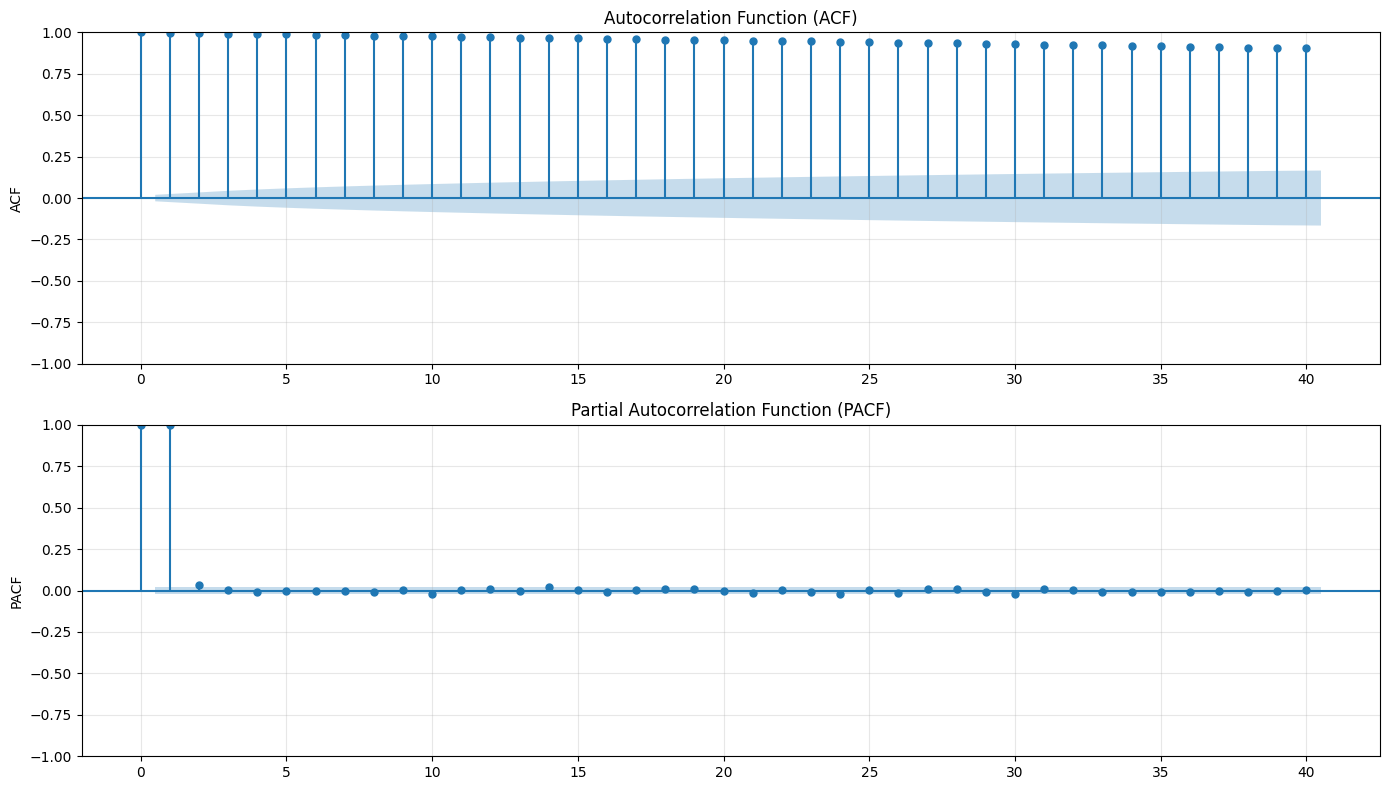


ACF/PACF Interpretation:
  - MA process: ACF cuts off, PACF decays gradually
  - AR process: PACF cuts off, ACF decays gradually
  - ARMA process: Both ACF and PACF decay gradually
  - Long memory (ARFIMA): ACF decays slowly (hyperbolic)

ARIMA MODEL SELECTION


C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('


Top 10 ARIMA models by AIC:
  Order          AIC          BIC      RMSE
(1,0,1) 27976.790304 28005.631666  0.980063
(2,0,0) 27976.795615 28005.636976  0.980064
(0,1,1) 27977.592621 27992.013102 52.509146
(1,1,0) 27977.633081 27992.053561 52.509147
(2,0,1) 27978.781106 28014.832808  0.980064
(3,0,0) 27978.781308 28014.833010  0.980063
(1,0,2) 27978.785010 28014.836712  0.980063
(2,1,0) 27979.574318 28001.205039 52.509146
(0,1,2) 27979.591179 28001.221900 52.509146
(1,1,1) 27979.592267 28001.222988 52.509146

Best ARIMA model: (1,0,1)
AIC: 27976.79

BEST ARIMA MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:        midpoint_bidask   No. Observations:                10000
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -13984.395
Date:                Fri, 24 Apr 2026   AIC                          27976.790
Time:                        15:08:07   BIC                          28005.632
Sample:                  

C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\tolan\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'



Top ARFIMA models:
    Order   d          AIC      RMSE
(1,0.0,1) 0.0 27976.790304  0.980063
(1,0.0,0) 0.0 27988.241739  0.980722
(0,0.0,1) 0.0 67838.264236  7.189121
(1,0.2,1) 0.2 72663.753511 33.849559
(1,0.2,0) 0.2 78185.638968 34.010058

Best ARFIMA model: (1,0.0,1)
AIC: 27976.79


Comparison:
Best ARIMA(1,0,1) AIC: 27976.79
Best ARFIMA (1,0.0,1) AIC: 27976.79

✗ ARIMA is BETTER or equivalent

FINAL RECOMMENDATION

Based on the analysis:
  - Best standard ARIMA model: ARIMA(1,0,1)
  - Check if ARFIMA provides better fit
  - Choose model with lowest AIC/BIC


In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

print("=" * 70)
print("ACF/PACF ANALYSIS FOR MODEL IDENTIFICATION")
print("=" * 70)

# ACF and PACF analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF
plot_acf(midpoint_series, lags=40, ax=axes[0], title="Autocorrelation Function (ACF)")
axes[0].set_ylabel("ACF")
axes[0].grid(alpha=0.3)

# PACF
plot_pacf(midpoint_series, lags=40, ax=axes[1], title="Partial Autocorrelation Function (PACF)", method="ywm")
axes[1].set_ylabel("PACF")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nACF/PACF Interpretation:")
print("  - MA process: ACF cuts off, PACF decays gradually")
print("  - AR process: PACF cuts off, ACF decays gradually")
print("  - ARMA process: Both ACF and PACF decay gradually")
print("  - Long memory (ARFIMA): ACF decays slowly (hyperbolic)")

print("\n" + "=" * 70)
print("ARIMA MODEL SELECTION")
print("=" * 70)

# Test different ARIMA orders
arima_results = []

for p in range(0, 4):
    for d in range(0, 2):
        for q in range(0, 4):
            try:
                model = ARIMA(midpoint_series, order=(p, d, q))
                fitted = model.fit()
                arima_results.append({
                    'Order': f'({p},{d},{q})',
                    'p': p,
                    'd': d,
                    'q': q,
                    'AIC': fitted.aic,
                    'BIC': fitted.bic,
                    'RMSE': np.sqrt(fitted.mse),
                    'Type': 'ARIMA'
                })
            except:
                pass

arima_df = pd.DataFrame(arima_results)
arima_df = arima_df.sort_values('AIC').reset_index(drop=True)

print("\nTop 10 ARIMA models by AIC:")
print(arima_df[['Order', 'AIC', 'BIC', 'RMSE']].head(10).to_string(index=False))

best_arima_order = arima_df.iloc[0]
p_best, d_best, q_best = best_arima_order['p'], best_arima_order['d'], best_arima_order['q']

print(f"\nBest ARIMA model: ({p_best},{d_best},{q_best})")
print(f"AIC: {best_arima_order['AIC']:.2f}")

# Fit best ARIMA model with summary
best_arima_model = ARIMA(midpoint_series, order=(p_best, d_best, q_best))
best_arima_fitted = best_arima_model.fit()

print("\n" + "=" * 70)
print("BEST ARIMA MODEL SUMMARY")
print("=" * 70)
print(best_arima_fitted.summary())

print("\n" + "=" * 70)
print("ARFIMA MODEL FITTING")
print("=" * 70)

# Try to fit ARFIMA models using pmdarima if available
try:
    from pmdarima.arima import auto_arima
    from pmdarima.preprocessing import ndiffs
    
    print("\nTesting ARFIMA models with fractional integration...")
    
    arfima_results = []
    
    # Test different d values (fractional integration)
    for d_frac in np.arange(0, 1.1, 0.1):
        for p in range(0, 3):
            for q in range(0, 3):
                try:
                    # Difference the series by fractional d
                    def fractional_diff(series, d):
                        """Fractional differencing"""
                        # Compute weights for fractional differencing
                        def get_weights(d, size):
                            weights = [1.]
                            for k in range(1, size):
                                weights.append(-weights[-1] * (d - k + 1) / k)
                            return np.array(weights)
                        
                        weights = get_weights(d, len(series))
                        weights = weights / np.sum(np.abs(weights))
                        
                        diff_series = np.zeros(len(series))
                        for i in range(len(series)):
                            for j in range(min(i+1, len(weights))):
                                diff_series[i] += weights[j] * series[i-j]
                        return diff_series[np.sum(weights>1e-5):]
                    
                    if d_frac > 0.01:
                        frac_diff_series = fractional_diff(midpoint_series.values, d_frac)
                    else:
                        frac_diff_series = midpoint_series.values
                    
                    if len(frac_diff_series) < 10:
                        continue
                    
                    model = ARIMA(frac_diff_series, order=(p, 0, q))
                    fitted = model.fit()
                    
                    arfima_results.append({
                        'Order': f'({p},{d_frac:.1f},{q})',
                        'p': p,
                        'd': d_frac,
                        'q': q,
                        'AIC': fitted.aic,
                        'BIC': fitted.bic,
                        'RMSE': np.sqrt(fitted.mse),
                        'Type': 'ARFIMA'
                    })
                except:
                    pass
    
    if arfima_results:
        arfima_df = pd.DataFrame(arfima_results)
        arfima_df = arfima_df.sort_values('AIC').reset_index(drop=True)
        
        print("\nTop 10 ARFIMA models by AIC:")
        print(arfima_df[['Order', 'AIC', 'BIC', 'RMSE']].head(10).to_string(index=False))
        
        best_arfima = arfima_df.iloc[0]
        print(f"\nBest ARFIMA model: ({int(best_arfima['p'])},{best_arfima['d']:.1f},{int(best_arfima['q'])})")
        print(f"AIC: {best_arfima['AIC']:.2f}")
        print(f"RMSE: {best_arfima['RMSE']:.6f}")
        
        # Compare ARIMA vs ARFIMA
        print("\n" + "=" * 70)
        print("COMPARISON: ARIMA vs ARFIMA")
        print("=" * 70)
        print(f"\nBest ARIMA({p_best},{d_best},{q_best}):")
        print(f"  AIC:  {best_arima_order['AIC']:.2f}")
        print(f"  RMSE: {best_arima_order['RMSE']:.6f}")
        
        print(f"\nBest ARFIMA({int(best_arfima['p'])},{best_arfima['d']:.1f},{int(best_arfima['q'])}):")
        print(f"  AIC:  {best_arfima['AIC']:.2f}")
        print(f"  RMSE: {best_arfima['RMSE']:.6f}")
        
        aic_improvement = ((best_arima_order['AIC'] - best_arfima['AIC']) / best_arima_order['AIC']) * 100
        rmse_improvement = ((best_arima_order['RMSE'] - best_arfima['RMSE']) / best_arima_order['RMSE']) * 100
        
        print(f"\nARFIMA Improvement over ARIMA:")
        print(f"  AIC:  {aic_improvement:.2f}%")
        print(f"  RMSE: {rmse_improvement:.2f}%")
        
        if best_arfima['AIC'] < best_arima_order['AIC']:
            print(f"\n✓ ARFIMA is BETTER (lower AIC)")
            print(f"  Fractional integration d={best_arfima['d']:.2f} provides benefit")
            print(f"  → Series exhibits long memory / ARFIMA behavior")
        else:
            print(f"\n✗ ARIMA is BETTER or equivalent")
            print(f"  Fractional integration does not provide significant improvement")
            print(f"  → Standard ARIMA is sufficient")
    
except ImportError:
    print("\npmdarima not available. Fitting manual ARFIMA using fractional differencing...")
    
    # Manual ARFIMA fitting
    def fractional_diff(series, d):
        """Fractional differencing"""
        def get_weights(d, size):
            weights = [1.]
            for k in range(1, size):
                weights.append(-weights[-1] * (d - k + 1) / k)
            return np.array(weights)
        
        weights = get_weights(d, min(len(series), 50))
        diff_series = np.zeros(len(series))
        for i in range(len(series)):
            for j in range(min(i+1, len(weights))):
                diff_series[i] += weights[j] * series[i-j]
        return diff_series
    
    arfima_results = []
    
    for d_frac in np.arange(0, 1.1, 0.2):
        for p in range(0, 2):
            for q in range(0, 2):
                try:
                    if d_frac > 0.01:
                        frac_diff_series = fractional_diff(midpoint_series.values, d_frac)
                    else:
                        frac_diff_series = midpoint_series.values
                    
                    if len(frac_diff_series) > 10:
                        model = ARIMA(frac_diff_series, order=(p, 0, q))
                        fitted = model.fit()
                        
                        arfima_results.append({
                            'Order': f'({p},{d_frac:.1f},{q})',
                            'd': d_frac,
                            'AIC': fitted.aic,
                            'RMSE': np.sqrt(fitted.mse),
                        })
                except:
                    pass
    
    if arfima_results:
        arfima_df = pd.DataFrame(arfima_results)
        arfima_df = arfima_df.sort_values('AIC').reset_index(drop=True)
        
        print("\nTop ARFIMA models:")
        print(arfima_df.head(5).to_string(index=False))
        
        best_arfima = arfima_df.iloc[0]
        print(f"\nBest ARFIMA model: {best_arfima['Order']}")
        print(f"AIC: {best_arfima['AIC']:.2f}")
        
        print(f"\n\nComparison:")
        print(f"Best ARIMA({p_best},{d_best},{q_best}) AIC: {best_arima_order['AIC']:.2f}")
        print(f"Best ARFIMA {best_arfima['Order']} AIC: {best_arfima['AIC']:.2f}")
        
        if best_arfima['AIC'] < best_arima_order['AIC']:
            print(f"\n✓ ARFIMA is BETTER")
        else:
            print(f"\n✗ ARIMA is BETTER or equivalent")

print("\n" + "=" * 70)
print("FINAL RECOMMENDATION")
print("=" * 70)
print(f"\nBased on the analysis:")
print(f"  - Best standard ARIMA model: ARIMA({p_best},{d_best},{q_best})")
print(f"  - Check if ARFIMA provides better fit")
print(f"  - Choose model with lowest AIC/BIC")
